# Model Preprocessing and Combination with Human Data

## First, let's preprocess the model data sheets into one summarized long data sheet

In [25]:
%reset -f

In [ ]:
'''
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

base_cols = ['experiment_label', 
                'id', #subject identifier
                'condition', #condition (natural, feature, shape)
                'animacy', #animacy (only if animacy_inclusion is True)
                'filtered_acc', #accuracy after filtering
                ]
conditions = ['natural', 'feature', 'shape']
model_archs = ['convnext', 'vit']

#animacies = ['anim_natural', 'inanim_natural', 'inanim_artificial']


experiments = ['familiar', 'novel']

rows_familiar = []
rows_novel = []

for experiment in experiments:

    for model_arch in model_archs:
        if experiment == 'familiar':
            file_path = f'/zpool/vladlab/data_drive/glint_master/data/model_data/{experiment}/{model_arch}_KNN_all_conditions_9way_new.csv'
            animacies = ['anim_natural', 'inanim_natural', 'inanim_artificial']
            model = pd.read_csv(file_path)
        elif experiment == 'novel':
            file_path = f'/zpool/vladlab/data_drive/glint_master/data/model_data/{experiment}/{model_arch}_KNN_all_conditions_4way_novel.csv'
            animacies = ['inanim_artificial']
            model = pd.read_csv(file_path)
            

        # Read in the model results CSV file
        model = pd.read_csv(file_path)

        # if test_animacy not in columns, make it (inanim_artificial as this is only a novel problem)
        if "test_animacy" not in model.columns:
            model["test_animacy"] = "inanim_artificial"

        #Create a temporary data frame
        #condition_summary = pd.DataFrame(columns=base_cols)
        
        #Loop through conditions
        for condition in conditions:
            #Loop through animacies
            for animacy in animacies:
                model_by_condition = model[
                    (model['condition'] == condition) & 
                    (model['test_animacy'] == animacy) 
                    #(combined_model_results_familiar['model'] == model_arch)] #if not extreme, we don't need to filter by stimulus duration, so we only filter by condition and animacy
                ]
                # Calculate accuracy
                filtered_acc = model_by_condition['acc'].mean()

                row = {
                'experiment_label': f'{experiment}_glint', #experiment and extreme status
                'id': model_arch, #subject identifier
                'condition': condition, #condition (natural, scrambled, line_drawing)
                'animacy': animacy, #animacy (only if animacy_inclusion is True)
                'filtered_acc': filtered_acc, #accuracy after filtering
    
                }
                if experiment == 'familiar':
                    rows_familiar.append(row)
                elif experiment == 'novel':
                    rows_novel.append(row)

                
                #condition_summary = pd.concat([condition_summary, pd.DataFrame([row])], ignore_index=True) #append the row to the condition summary

familiar_model_summary_df = pd.DataFrame(rows_familiar)
novel_model_summary_df = pd.DataFrame(rows_novel)

familiar_model_summary_df["model_or_human"] = familiar_model_summary_df["id"].astype(str)
novel_model_summary_df["model_or_human"] = novel_model_summary_df["id"].astype(str)
'''

In [1]:
# ...existing code...
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

# Keep raw rows; only standardize/add columns
col_map = {
    "model": "id",
    "test_animacy": "animacy",
    "acc": "filtered_acc",
}

conditions = ['natural', 'feature', 'shape']
model_archs = ['convnext', 'vit', 'clip_vit', 'vit_dinov2']
experiments = ['novel', 'familiar']

full_familiar = []
full_novel = []

for experiment in experiments:
    for model_arch in model_archs:
        if experiment == "familiar":
            file_path = f"/zpool/vladlab/active_drive/arsch/GLINT/glint_modeling/results_{experiment}/{model_arch}_KNN_all_conditions_9way_new.csv"
        elif experiment == "novel":
            file_path = f"/zpool/vladlab/active_drive/arsch/GLINT/glint_modeling/results_{experiment}/{model_arch}_KNN_all_conditions_4way_novel.csv"

        model = pd.read_csv(file_path).copy()
        model = model.rename(columns=col_map)

        # add/fill required columns (no summarizing)
        if "animacy" not in model.columns:
            model["animacy"] = "inanim_artificial"
        if "id" not in model.columns:
            model["id"] = model_arch

        model["experiment_label"] = f"{experiment}_glint"
        model["model_or_human"] = model["id"].astype(str)

        # optional: keep canonical + useful raw columns
        model = model[["experiment_label","id","condition","animacy","filtered_acc","model_or_human"]]

        if experiment == "familiar":
            full_familiar.append(model)
        else:
            full_novel.append(model)

familiar_model_summary_df = pd.concat(full_familiar, ignore_index=True)
novel_model_summary_df = pd.concat(full_novel, ignore_index=True)


### Save the Model Summary Data

In [7]:

#Save the model summary dataframes as csv files for later use in figure_generator_script

#Novel model summary dataframe
novel_model_summary_df.to_csv("/zpool/vladlab/data_drive/glint_master/data/model_data/summary_csv/novel_model_summary.csv", index=False)

#Familiar model summary dataframe
familiar_model_summary_df.to_csv("/zpool/vladlab/data_drive/glint_master/data/model_data/summary_csv/familiar_model_summary.csv", index=False)

## Now let's combine the model with the human data

In [2]:
# import the human data 
human_familiar_file_path = '/zpool/vladlab/data_drive/glint_master/data/adult_data/summary_data_csv/familiar_glint_original_cleaned.csv' # Path
human_familiar_df = pd.read_csv(human_familiar_file_path) #Read in data
human_familiar_df = human_familiar_df.rename(columns={"sub": "id"}) #Rename sub to id
human_familiar_df["model_or_human"] = "human" #Add identifying variable for figures


human_novel_file_path = '/zpool/vladlab/data_drive/glint_master/data/adult_data/summary_data_csv/novel_glint_original_cleaned.csv' # Path 
human_novel_df = pd.read_csv(human_novel_file_path) # Read in data
human_novel_df = human_novel_df.rename(columns={"sub": "id"}) #Rename sub to id
human_novel_df["model_or_human"] = "human" #Add identifying variable for figures

combined_familiar_df = pd.concat([human_familiar_df, familiar_model_summary_df], ignore_index = True ) #Combine them

combined_novel_df = pd.concat([human_novel_df, novel_model_summary_df], ignore_index = True) # Combine them


### Save the Data

In [6]:
combined_familiar_df.to_csv("/zpool/vladlab/data_drive/glint_master/data/model_data/summary_csv/human_model_combo_familiar_summary.csv", index=False)

combined_novel_df.to_csv("/zpool/vladlab/data_drive/glint_master/data/model_data/summary_csv/human_model_combo_novel_summary.csv", index=False)

### Quick plot and stats

<Axes: xlabel='condition', ylabel='filtered_acc'>

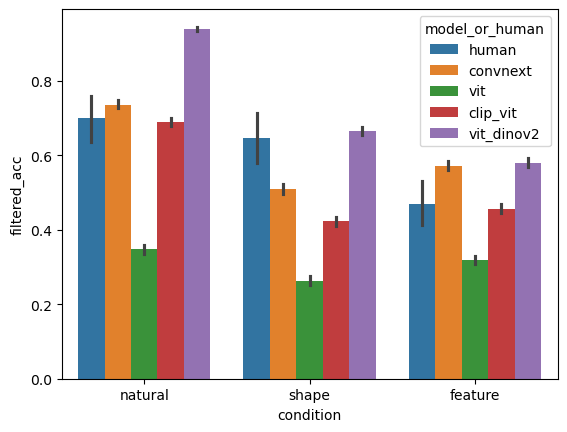

In [4]:
condition_order = ["natural", "shape", "feature"]


sns.barplot(
    data= combined_novel_df, 
    x = "condition",
    y = "filtered_acc",
    hue = "model_or_human",
    order = condition_order,
    errorbar="ci")

In [5]:
stats = (combined_novel_df
         .groupby(["model_or_human", "condition"])["filtered_acc"]
         .agg(n="count", sd="std", mean="mean")
         .reset_index())
stats["se"] = stats["sd"] / (stats["n"] ** 0.5)
stats["ci95"] = 1.96 * stats["se"]
print(stats)

   model_or_human condition     n        sd      mean        se      ci95
0        clip_vit   feature  6480  0.498087  0.455864  0.006188  0.012128
1        clip_vit   natural  6480  0.463110  0.688580  0.005753  0.011276
2        clip_vit     shape  6480  0.494000  0.422531  0.006137  0.012028
3        convnext   feature  6480  0.494884  0.571605  0.006148  0.012050
4        convnext   natural  6480  0.440939  0.735802  0.005478  0.010736
5        convnext     shape  6480  0.499953  0.509259  0.006211  0.012173
6           human   feature    50  0.220227  0.470153  0.031145  0.061044
7           human   natural    50  0.224071  0.699301  0.031688  0.062109
8           human     shape    50  0.252457  0.646906  0.035703  0.069977
9             vit   feature  6480  0.465938  0.318519  0.005788  0.011345
10            vit   natural  6480  0.476025  0.346914  0.005913  0.011590
11            vit     shape  6480  0.440443  0.263272  0.005471  0.010724
12     vit_dinov2   feature  6480  0.4